In [10]:
import pandas as pd
import boto3
from io import StringIO

# ============================================================================
# INSPECT JOINED DATASET FOR BACKTEST
# ============================================================================

# Setup S3 client
s3_client = boto3.client('s3')

# Choose which season and strategy type to inspect
SEASON = '2024-25'  # or '2023-24'
STRATEGY_TYPE = '2d'  # or '3d' (use '3d' to see _rim40.csv with scorer_type)

# Load data from S3
bucket = 'nba-betting-mt'
if STRATEGY_TYPE == '3d':
    key = f'data/03_intermediate/player_props_with_actuals_{SEASON}_rim40.csv'
else:
    key = f'data/03_intermediate/player_props_with_actuals_{SEASON}.csv'

print(f"Loading: s3://{bucket}/{key}")
response = s3_client.get_object(Bucket=bucket, Key=key)
df = pd.read_csv(StringIO(response['Body'].read().decode('utf-8')))

print(f"\n✅ Loaded {len(df):,} rows\n")

# ============================================================================
# KEY COLUMNS FOR BACKTEST
# ============================================================================
key_cols = [
    'GAME_DATE',
    'PLAYER_NAME', 
    'TEAM_NAME',
    'MATCHUP',
    'PTS',  # actual points scored
    'points_line',  # betting line
    'team_spread',  # game spread
    'is_favorite',
    'scorer_type',  # only in 3D
]

# Filter to columns that exist
available_cols = [c for c in key_cols if c in df.columns]
df_inspect = df[available_cols].copy()

# ============================================================================
# SHOW SAMPLE ROWS
# ============================================================================
print("="*80)
print("SAMPLE ROWS (first 10)")
print("="*80)
print(df_inspect.head(10).to_string())

# ============================================================================
# CHECK FOR NULL VALUES IN KEY COLUMNS
# ============================================================================
print("\n" + "="*80)
print("NULL VALUE COUNTS")
print("="*80)
for col in available_cols:
    null_count = df[col].isna().sum()
    null_pct = (null_count / len(df)) * 100
    print(f"{col:25s}: {null_count:6,} ({null_pct:5.1f}%)")

# ============================================================================
# FILTER TO ROWS WITH BETTING LINES (these are what backtest uses)
# ============================================================================
df_with_lines = df_inspect[df_inspect['points_line'].notna()].copy()
print(f"\n" + "="*80)
print(f"ROWS WITH BETTING LINES: {len(df_with_lines):,} / {len(df):,} ({len(df_with_lines)/len(df)*100:.1f}%)")
print("="*80)

# Calculate outcomes manually
df_with_lines['actual_vs_line'] = df_with_lines['PTS'] - df_with_lines['points_line']
df_with_lines['beat_over'] = df_with_lines['actual_vs_line'] > 0
df_with_lines['beat_under'] = df_with_lines['actual_vs_line'] < 0
df_with_lines['push'] = df_with_lines['actual_vs_line'] == 0

print("\nSample rows WITH betting lines:")
print(df_with_lines.head(10).to_string())

# ============================================================================
# STATISTICS
# ============================================================================
print("\n" + "="*80)
print("OVER/UNDER STATISTICS (all rows with betting lines)")
print("="*80)
print(f"Total rows: {len(df_with_lines):,}")
print(f"Beat OVER: {df_with_lines['beat_over'].sum():,} ({df_with_lines['beat_over'].sum()/len(df_with_lines)*100:.1f}%)")
print(f"Beat UNDER: {df_with_lines['beat_under'].sum():,} ({df_with_lines['beat_under'].sum()/len(df_with_lines)*100:.1f}%)")
print(f"Push: {df_with_lines['push'].sum():,} ({df_with_lines['push'].sum()/len(df_with_lines)*100:.1f}%)")
print(f"\nAverage actual points: {df_with_lines['PTS'].mean():.2f}")
print(f"Average line: {df_with_lines['points_line'].mean():.2f}")
print(f"Average difference (actual - line): {df_with_lines['actual_vs_line'].mean():.2f}")

# ============================================================================
# DISTRIBUTION BY PLAYER TIER (points line bins)
# ============================================================================
print("\n" + "="*80)
print("DISTRIBUTION BY POINTS LINE")
print("="*80)

def bin_points_line(line, granularity='detailed'):
    """Replicate binning logic from backtest"""
    if pd.isna(line):
        return None
    if granularity == 'detailed':
        if line < 5: return '0-5 (Minimal)'
        elif line < 10: return '5-10 (Bench)'
        elif line < 15: return '10-15 (Rotation)'
        elif line < 20: return '15-20 (Starter)'
        elif line < 25: return '20-25 (Key)'
        elif line < 30: return '25-30 (Star)'
        else: return '30+ (Superstar)'
    else:
        if line < 10: return '0-10'
        elif line < 20: return '10-20'
        elif line < 30: return '20-30'
        else: return '30+'

df_with_lines['line_tier'] = df_with_lines['points_line'].apply(bin_points_line)
tier_stats = df_with_lines.groupby('line_tier').agg({
    'PLAYER_NAME': 'count',
    'beat_over': 'sum',
    'beat_under': 'sum',
    'push': 'sum',
    'actual_vs_line': 'mean'
}).rename(columns={'PLAYER_NAME': 'count'})
tier_stats['over_pct'] = (tier_stats['beat_over'] / tier_stats['count'] * 100).round(1)
tier_stats['under_pct'] = (tier_stats['beat_under'] / tier_stats['count'] * 100).round(1)

print(tier_stats[['count', 'over_pct', 'under_pct', 'actual_vs_line']].to_string())

# ============================================================================
# CHECK A FEW SPECIFIC EXAMPLES
# ============================================================================
print("\n" + "="*80)
print("SAMPLE PLAYS (for manual verification)")
print("="*80)
sample = df_with_lines.sample(min(5, len(df_with_lines)), random_state=42)
for idx, row in sample.iterrows():
    pts = row['PTS']
    line = row['points_line']
    diff = pts - line
    result = 'PUSH' if diff == 0 else ('OVER wins' if diff > 0 else 'UNDER wins')
    print(f"\n{row['PLAYER_NAME']:20s} {row['GAME_DATE']}")
    print(f"  Line: {line:4.1f} | Actual: {pts:2.0f} | Diff: {diff:+5.1f} → {result}")

Loading: s3://nba-betting-mt/data/03_intermediate/player_props_with_actuals_2024-25.csv

✅ Loaded 26,423 rows

SAMPLE ROWS (first 10)
    GAME_DATE      PLAYER_NAME               TEAM_NAME      MATCHUP  PTS  points_line  team_spread is_favorite  scorer_type
0  2024-10-22    Anthony Davis      Los Angeles Lakers  LAL vs. MIN   36    24.884615         1.05        True          NaN
1  2024-10-22     Jayson Tatum          Boston Celtics  BOS vs. NYK   37    26.038462        -6.10        True          NaN
2  2024-10-22  Anthony Edwards  Minnesota Timberwolves    MIN @ LAL   27    26.428571        -1.05        True          NaN
3  2024-10-22    Derrick White          Boston Celtics  BOS vs. NYK   24    14.333333        -6.10        True          NaN
4  2024-10-22     Jaylen Brown          Boston Celtics  BOS vs. NYK   23    23.884615        -6.10        True          NaN
5  2024-10-22     Jrue Holiday          Boston Celtics  BOS vs. NYK   18    13.136364        -6.10        True          Na

In [11]:
...

Ellipsis

In [12]:
# %% [markdown]
# # Analysis: Profitable Backtest Strategies
# 
# Find strategies where backtest performance >= training performance

# %%
import pandas as pd
import boto3
from io import StringIO

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# %%
# Setup
s3_client = boto3.client('s3')
bucket = 'nba-betting-mt'

def find_latest_backtest(s3_client, bucket, strategy_type):
    """
    Find the most recent backtest results for a strategy type
    by listing all files and picking the latest timestamp
    """
    prefix = 'data/04_output/backtests/'
    
    try:
        response = s3_client.list_objects_v2(
            Bucket=bucket,
            Prefix=prefix
        )
        
        if 'Contents' not in response:
            return None
        
        # Find all matching files
        matching_files = [
            obj['Key'] for obj in response['Contents']
            if f'{strategy_type}_per_strategy_performance.csv' in obj['Key']
        ]
        
        if not matching_files:
            return None
        
        # Sort by key (timestamp in filename) and take the latest
        matching_files.sort(reverse=True)
        return matching_files[0]
        
    except Exception as e:
        print(f"Error listing S3 files: {e}")
        return None

# Try to find latest backtest results dynamically
print("🔍 Finding latest backtest results...\n")

backtests = []
for season in ['2024-25', '2023-24']:
    for strategy in ['2d', '3d']:
        path = find_latest_backtest(s3_client, bucket, strategy)
        
        if path:
            # Filter to correct season based on path content
            # For now, we'll use the manually specified paths as fallback
            backtests.append({
                'season': season,
                'strategy': strategy,
                'path': path
            })

# Use the new structured paths (organized by strategy type and season)
backtests = [
    {
        'season': '2024-25', 
        'strategy': '2d', 
        'path': 'data/04_output/backtests/2d/2024-25/per_strategy.csv'
    },
    {
        'season': '2024-25', 
        'strategy': '3d', 
        'path': 'data/04_output/backtests/3d/2024-25/per_strategy.csv'
    },
    {
        'season': '2023-24', 
        'strategy': '2d', 
        'path': 'data/04_output/backtests/2d/2023-24/per_strategy.csv'
    },
    {
        'season': '2023-24', 
        'strategy': '3d', 
        'path': 'data/04_output/backtests/3d/2023-24/per_strategy.csv'
    },
]

# %% [markdown]
# ## Load All Backtest Results

# %%
all_results = []

for backtest in backtests:
    try:
        response = s3_client.get_object(Bucket=bucket, Key=backtest['path'])
        df = pd.read_csv(StringIO(response['Body'].read().decode('utf-8')))
        df['season'] = backtest['season']
        df['strategy_type'] = backtest['strategy']
        all_results.append(df)
        print(f"✅ Loaded {backtest['season']} {backtest['strategy'].upper()}: {len(df)} strategies")
    except Exception as e:
        print(f"⚠️  Skipping {backtest['season']} {backtest['strategy'].upper()}: file not found")
        # print(f"   Path: {backtest['path']}")  # Uncomment to debug

if not all_results:
    raise ValueError("❌ No backtest results found! Make sure backtests have been run.")

df_all = pd.concat(all_results, ignore_index=True)
print(f"\n📊 Total strategies analyzed: {len(df_all)}")
print(f"📊 From {len(all_results)} backtest file(s)")

# %% [markdown]
# ## Helper Function: Analyze Winners

# %%
def analyze_winners(df, title):
    """Analyze profitable strategies that generalized well"""
    winners = df[(df['backtest_roi'] > 0) & (df['roi_delta'] >= 0)].copy()
    
    print(f"\n{'='*80}")
    print(f"📊 {title}")
    print(f"{'='*80}")
    
    if len(winners) == 0:
        print(f"❌ No profitable strategies found that generalized well")
        return winners
    
    print(f"✅ Profitable strategies: {len(winners)} / {len(df)} ({len(winners)/len(df)*100:.1f}%)")
    print(f"💰 Total profit: ${winners['backtest_profit'].sum():,.2f}")
    print(f"📈 Average ROI: {winners['backtest_roi'].mean():+.2f}%")
    print(f"🎯 Average win rate: {winners['backtest_win_rate'].mean():.1f}%")
    print(f"🎲 Total plays: {winners['backtest_plays'].sum():.0f}")
    
    # By strategy type
    if len(winners) > 0:
        strategy_summary = winners.groupby('strategy_type').agg({
            'strategy_idx': 'count',
            'backtest_profit': 'sum',
            'backtest_roi': 'mean',
            'backtest_win_rate': 'mean',
            'backtest_plays': 'sum'
        }).rename(columns={'strategy_idx': 'num_strategies'})
        
        print(f"\nBy Strategy Type:")
        for strat_type in strategy_summary.index:
            row = strategy_summary.loc[strat_type]
            print(f"  {strat_type.upper()}: {row['num_strategies']:.0f} strategies | "
                  f"${row['backtest_profit']:,.2f} profit | "
                  f"{row['backtest_roi']:+.1f}% ROI | "
                  f"{row['backtest_win_rate']:.1f}% win rate")
    
    # Top 3 strategies
    if len(winners) > 0:
        print(f"\n🏆 Top 3 Strategies:")
        top_3 = winners.nlargest(3, 'backtest_roi')
        for idx, row in top_3.iterrows():
            print(f"\n  #{idx}: {row['line_tier']} | {row['spread_bin']} | {row['bet_side']}")
            if row['scorer_type'] != 'N/A':
                print(f"      Scorer: {row['scorer_type']}")
            print(f"      Training: {row['training_roi']:+.1f}% ROI | Backtest: {row['backtest_roi']:+.1f}% ROI (+{row['roi_delta']:.1f}%)")
            print(f"      {row['backtest_plays']:.0f} plays | ${row['backtest_profit']:,.2f} profit")
    
    return winners

# %% [markdown]
# ## Section 1: 2023-24 Season Analysis

# %%
df_2023 = df_all[df_all['season'] == '2023-24'].copy()
winners_2023 = analyze_winners(df_2023, "2023-24 SEASON ANALYSIS")

# %% [markdown]
# ## Section 2: 2024-25 Season Analysis

# %%
df_2024 = df_all[df_all['season'] == '2024-25'].copy()
winners_2024 = analyze_winners(df_2024, "2024-25 SEASON ANALYSIS")

# %% [markdown]
# ## Section 3: Combined Analysis (All Seasons)

# %%
winners_all = analyze_winners(df_all, "COMBINED ANALYSIS (ALL SEASONS)")

# %% [markdown]
# ## Final Summary: Compare All 3 Analyses

# %%
print(f"\n{'='*80}")
print(f"📈 FINAL SUMMARY: BACKTEST RESULTS")
print(f"{'='*80}")

print(f"\n2023-24 Season:")
print(f"  Total Strategies: {len(df_2023)}")
print(f"  Winners: {len(winners_2023)} ({len(winners_2023)/len(df_2023)*100:.1f}%)")
if len(winners_2023) > 0:
    print(f"  Profit: ${winners_2023['backtest_profit'].sum():,.2f}")
    print(f"  Avg ROI: {winners_2023['backtest_roi'].mean():+.1f}%")
    print(f"  Best Strategy: {winners_2023.nlargest(1, 'backtest_roi')['backtest_roi'].values[0]:+.1f}% ROI")

print(f"\n2024-25 Season:")
print(f"  Total Strategies: {len(df_2024)}")
print(f"  Winners: {len(winners_2024)} ({len(winners_2024)/len(df_2024)*100:.1f}%)")
if len(winners_2024) > 0:
    print(f"  Profit: ${winners_2024['backtest_profit'].sum():,.2f}")
    print(f"  Avg ROI: {winners_2024['backtest_roi'].mean():+.1f}%")
    print(f"  Best Strategy: {winners_2024.nlargest(1, 'backtest_roi')['backtest_roi'].values[0]:+.1f}% ROI")

print(f"\nCombined (All Seasons):")
print(f"  Total Strategies: {len(df_all)}")
print(f"  Winners: {len(winners_all)} ({len(winners_all)/len(df_all)*100:.1f}%)")
if len(winners_all) > 0:
    print(f"  Total Profit: ${winners_all['backtest_profit'].sum():,.2f}")
    print(f"  Avg ROI: {winners_all['backtest_roi'].mean():+.1f}%")
    print(f"  Best Strategy: {winners_all.nlargest(1, 'backtest_roi')['backtest_roi'].values[0]:+.1f}% ROI")

print(f"\n{'='*80}")
print(f"🎯 KEY INSIGHTS")
print(f"{'='*80}")

# Compare seasons
if len(winners_2023) > len(winners_2024):
    print(f"✅ 2023-24 had MORE successful strategies ({len(winners_2023)} vs {len(winners_2024)})")
elif len(winners_2024) > len(winners_2023):
    print(f"✅ 2024-25 had MORE successful strategies ({len(winners_2024)} vs {len(winners_2023)})")
else:
    print(f"⚖️  Both seasons had equal number of successful strategies ({len(winners_2023)})")

# Check if any strategies worked across both seasons
if len(winners_all) > 0:
    # Group by strategy characteristics to see if same setups worked in both seasons
    for season in ['2023-24', '2024-25']:
        season_winners = winners_all[winners_all['season'] == season]
        if len(season_winners) > 0:
            print(f"\n{season}:")
            for idx, row in season_winners.nlargest(3, 'backtest_roi').iterrows():
                print(f"  • {row['line_tier']} | {row['spread_bin']} | {row['bet_side']} ({row['strategy_type'].upper()})")
                print(f"    → {row['backtest_roi']:+.1f}% ROI | ${row['backtest_profit']:,.2f} profit")

# %% [markdown]
# ## Export Results

# %%
# Save full results
if len(winners_all) > 0:
    winners_sorted = winners_all.sort_values('backtest_roi', ascending=False)
    output_file = 'profitable_strategies_summary.csv'
    winners_sorted.to_csv(output_file, index=False)
    print(f"\n✅ Saved {len(winners_sorted)} profitable strategies to: {output_file}")
    
    # Show a preview
    display_cols = [
        'season', 'strategy_type', 'line_tier', 'spread_bin', 'bet_side', 'scorer_type',
        'training_roi', 'backtest_roi', 'roi_delta', 
        'backtest_win_rate', 'backtest_plays', 'backtest_profit'
    ]
    print(f"\nPreview:")
    print(winners_sorted[display_cols].head(20))
else:
    print(f"\n❌ No profitable strategies to export")

# %%



🔍 Finding latest backtest results...

✅ Loaded 2024-25 2D: 8 strategies
✅ Loaded 2024-25 3D: 16 strategies
✅ Loaded 2023-24 2D: 8 strategies
✅ Loaded 2023-24 3D: 16 strategies

📊 Total strategies analyzed: 48
📊 From 4 backtest file(s)

📊 2023-24 SEASON ANALYSIS
✅ Profitable strategies: 7 / 24 (29.2%)
💰 Total profit: $19,719.00
📈 Average ROI: +15.54%
🎯 Average win rate: 60.5%
🎲 Total plays: 1523

By Strategy Type:
  2D: 3 strategies | $10,836.87 profit | +11.2% ROI | 58.2% win rate
  3D: 4 strategies | $8,882.13 profit | +18.8% ROI | 62.3% win rate

🏆 Top 3 Strategies:

  #46: 5-10 (Bench) | 10-15 Fav | UNDER
      Scorer: Perimeter (<40.0%)
      Training: +10.0% ROI | Backtest: +31.3% ROI (+21.3%)
      48 plays | $1,500.03 profit

  #37: 20-25 (Star) | 2-6 Dog | UNDER
      Scorer: Rim Attacker (≥40.0%)
      Training: +15.9% ROI | Backtest: +17.8% ROI (+1.9%)
      150 plays | $2,663.72 profit

  #36: 15-20 (High Role) | Pick'em (-2 to +2) | UNDER
      Scorer: Perimeter (<40.0%)
  

✅ Loaded 70 2D training strategies from 2025-26
✅ Loaded 100 3D training strategies from 2025-26

📊 Winning Strategies (ROI >= 5.0%):
  2D: 8 strategies
  3D: 16 strategies
✅ Loaded 1785 2D plays from 2023-24
✅ Loaded 2268 2D plays from 2024-25
✅ Loaded 2081 3D plays from 2023-24
✅ Loaded 2842 3D plays from 2024-25

📊 Total Plays Loaded:
  2D: 4,053 plays
  3D: 4,923 plays

📈 Cumulative Returns Calculated:
  2D: 4,053 plays across 8 strategies
  3D: 4,923 plays across 16 strategies
✅ Saved 2D strategy returns plot: tmp/2d_strategy_returns_over_time.png


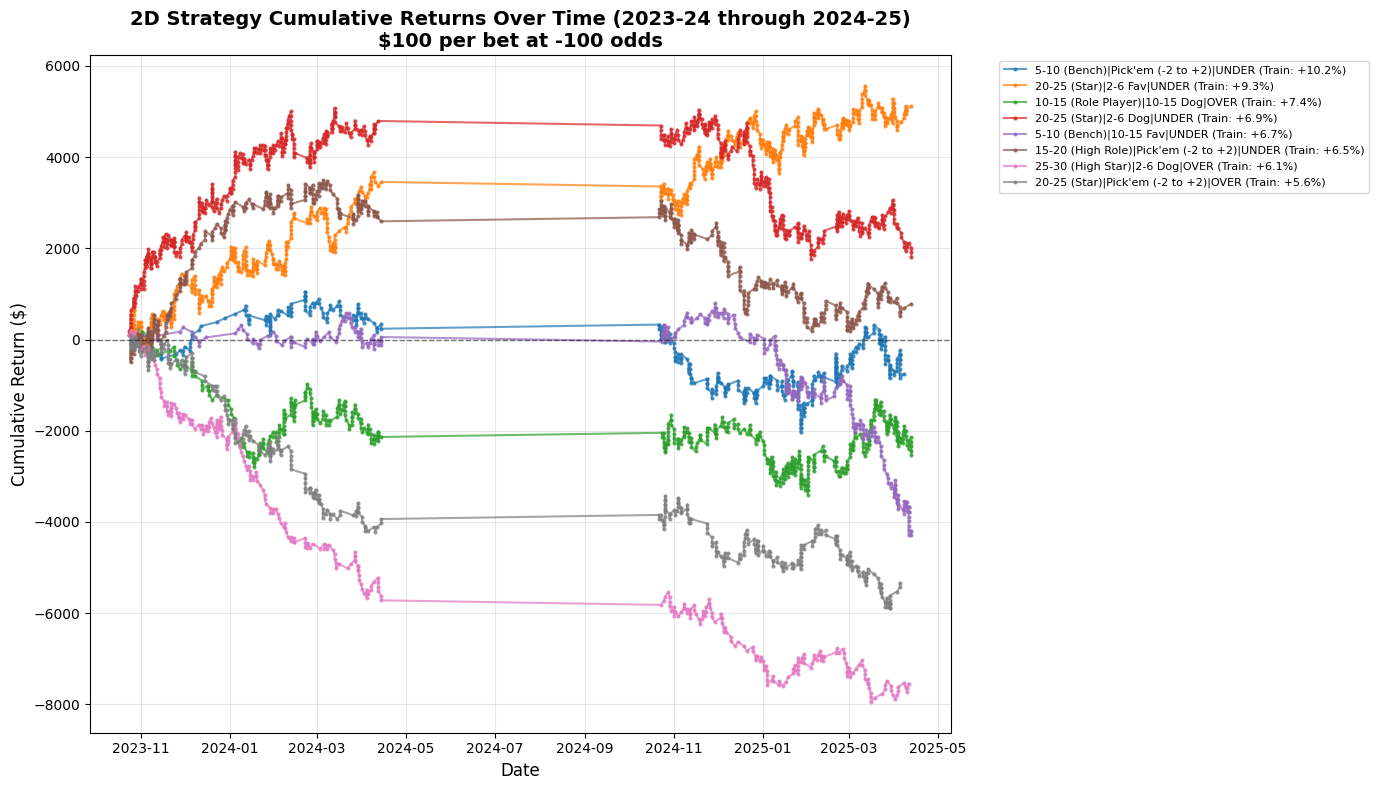

✅ Saved 3D strategy returns plot: tmp/3d_strategy_returns_over_time.png


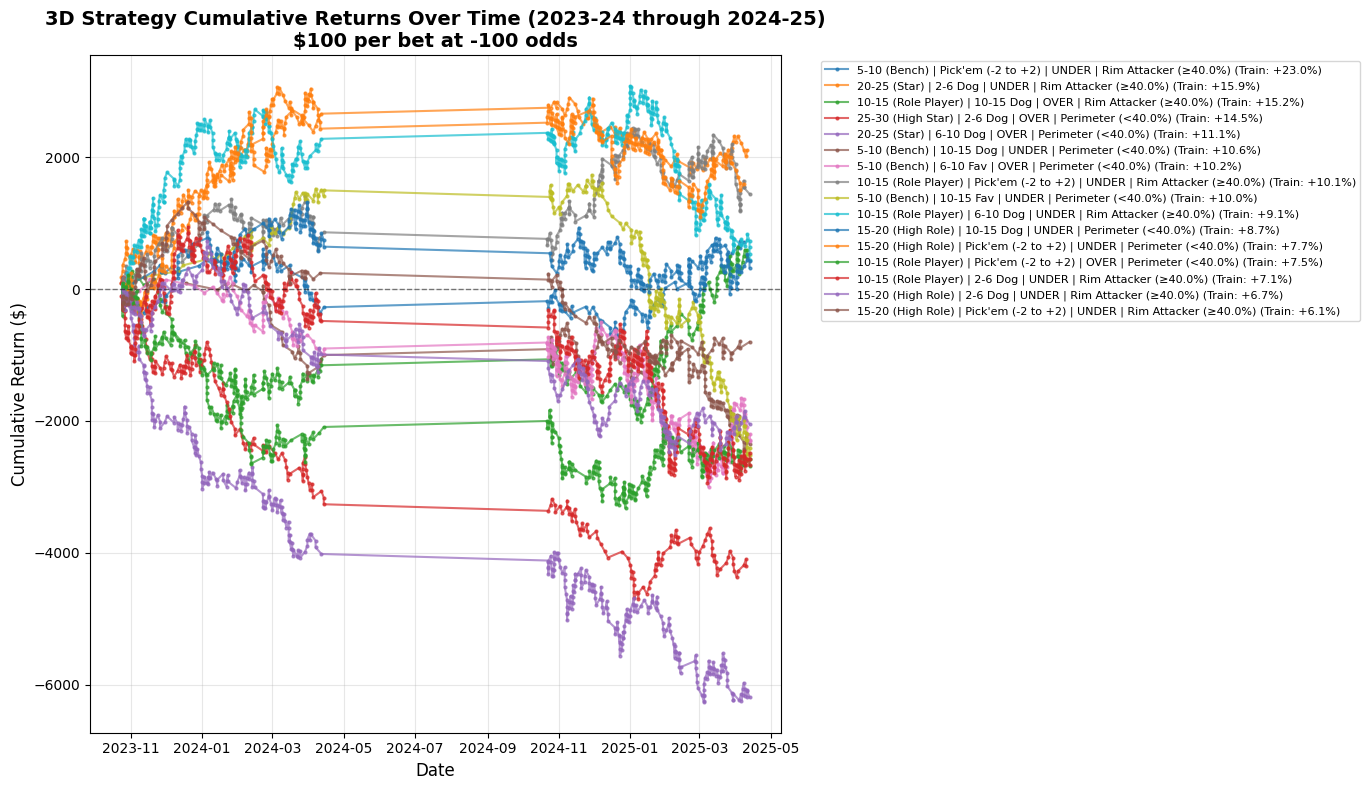


📊 2D STRATEGY SUMMARY

5-10 (Bench)|Pick'em (-2 to +2)|UNDER
  Training ROI: +10.2%
  Total Plays: 439
  W-L-P: 226-213-0
  Win Rate: 51.5%
  Final Return: $-754.34

20-25 (Star)|2-6 Fav|UNDER
  Training ROI: +9.3%
  Total Plays: 682
  W-L-P: 384-298-0
  Win Rate: 56.3%
  Final Return: $5,109.44

10-15 (Role Player)|10-15 Dog|OVER
  Training ROI: +7.4%
  Total Plays: 580
  W-L-P: 290-289-1
  Win Rate: 50.1%
  Final Return: $-2,536.10

20-25 (Star)|2-6 Dog|UNDER
  Training ROI: +6.9%
  Total Plays: 717
  W-L-P: 384-331-2
  Win Rate: 53.7%
  Final Return: $1,809.44

5-10 (Bench)|10-15 Fav|UNDER
  Training ROI: +6.7%
  Total Plays: 356
  W-L-P: 164-192-0
  Win Rate: 46.1%
  Final Return: $-4,290.76

15-20 (High Role)|Pick'em (-2 to +2)|UNDER
  Training ROI: +6.5%
  Total Plays: 543
  W-L-P: 288-254-1
  Win Rate: 53.1%
  Final Return: $782.08

25-30 (High Star)|2-6 Dog|OVER
  Training ROI: +6.1%
  Total Plays: 337
  W-L-P: 137-200-0
  Win Rate: 40.7%
  Final Return: $-7,545.33

20-25 (Sta

In [13]:
# %% [markdown]
# # Strategy Returns Over Time (2023-24 through 2025-26)
# 
# For each strategy with ROI >= 5.0% in 2025-26 training data:
# - Track cumulative returns across all 3 seasons
# - Plot each strategy as a separate line
# - Assume $100 per bet at -100 odds (even money)
# - Separate graphs for 2D and 3D strategies

# %%
import pandas as pd
import boto3
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# %%
# Setup
s3_client = boto3.client('s3')
bucket = 'nba-betting-mt'

# %% [markdown]
# ## Step 1: Load 2025-26 Training Strategies (to identify winning strategies)

# %%
def load_training_strategies(strategy_type):
    """Load 2025-26 training strategies from S3"""
    if strategy_type == '2d':
        s3_key = 'data/03_intermediate/points_by_role_gamespread_strategies_2025-26.json'
    else:  # 3d
        s3_key = 'data/03_intermediate/points_by_role_gamespread_6feet_strategies_2025-26_rim40.json'
    
    try:
        response = s3_client.get_object(Bucket=bucket, Key=s3_key)
        data = json.loads(response['Body'].read().decode('utf-8'))
        
        # Extract strategies list
        if 'strategies' in data:
            strategies = data['strategies']
        else:
            strategies = data
        
        # Convert to DataFrame for easier filtering
        if isinstance(strategies, dict):
            strategies = list(strategies.values())
        
        df = pd.DataFrame(strategies)
        print(f"✅ Loaded {len(df)} {strategy_type.upper()} training strategies from 2025-26")
        return df
        
    except Exception as e:
        print(f"❌ Error loading {strategy_type.upper()} training strategies: {e}")
        return pd.DataFrame()

# Load both strategy types
training_2d = load_training_strategies('2d')
training_3d = load_training_strategies('3d')

# Filter to winning strategies (ROI >= 5.0%)
winning_2d = training_2d[training_2d['roi'] >= 5.0].copy()
winning_3d = training_3d[training_3d['roi'] >= 5.0].copy()

print(f"\n📊 Winning Strategies (ROI >= 5.0%):")
print(f"  2D: {len(winning_2d)} strategies")
print(f"  3D: {len(winning_3d)} strategies")

# %% [markdown]
# ## Step 2: Load Backtest Results (per-play data for all seasons)

# %%
def load_backtest_plays(strategy_type, seasons=['2023-24', '2024-25']):
    """Load detailed play-by-play backtest results from S3"""
    all_plays = []
    
    for season in seasons:
        s3_key = f'data/04_output/backtests/{strategy_type}/{season}/plays.csv'
        
        try:
            response = s3_client.get_object(Bucket=bucket, Key=s3_key)
            df = pd.read_csv(StringIO(response['Body'].read().decode('utf-8')))
            df['season'] = season
            all_plays.append(df)
            print(f"✅ Loaded {len(df)} {strategy_type.upper()} plays from {season}")
        except Exception as e:
            print(f"⚠️  Skipping {season} {strategy_type.upper()}: {e}")
    
    if all_plays:
        return pd.concat(all_plays, ignore_index=True)
    else:
        return pd.DataFrame()

# Load backtest plays
plays_2d = load_backtest_plays('2d')
plays_3d = load_backtest_plays('3d')

print(f"\n📊 Total Plays Loaded:")
print(f"  2D: {len(plays_2d):,} plays")
print(f"  3D: {len(plays_3d):,} plays")

# %% [markdown]
# ## Step 3: Calculate Cumulative Returns for Each Winning Strategy

# %%
def calculate_cumulative_returns(plays_df, winning_strategies_df, strategy_type):
    """
    Calculate cumulative returns over time for each winning strategy.
    
    Assumes:
    - $100 per bet
    - -100 odds (even money: win = +$100, loss = -$100)
    """
    results = []
    
    for idx, strat in winning_strategies_df.iterrows():
        # Create a unique identifier for this strategy
        strat_id = f"{strat['line_tier']}|{strat['spread_bin']}|{strat['bet_side']}"
        if strategy_type == '3d' and 'scorer_type' in strat:
            strat_id += f"|{strat['scorer_type']}"
        
        # Filter plays for this specific strategy
        strategy_plays = plays_df[
            (plays_df['line_tier'] == strat['line_tier']) &
            (plays_df['spread_bin'] == strat['spread_bin']) &
            (plays_df['bet_side'] == strat['bet_side'])
        ].copy()
        
        # For 3D, also match scorer_type
        if strategy_type == '3d' and 'scorer_type' in strat:
            strategy_plays = strategy_plays[
                strategy_plays['scorer_type'] == strat['scorer_type']
            ]
        
        if len(strategy_plays) == 0:
            continue
        
        # Sort by date
        strategy_plays = strategy_plays.sort_values('game_date')
        
        # Profit is already calculated in the plays CSV
        # Calculate cumulative return
        strategy_plays['cumulative_return'] = strategy_plays['profit'].cumsum()
        
        # Add strategy info
        strategy_plays['strategy_id'] = strat_id
        strategy_plays['training_roi'] = strat['roi']
        
        results.append(strategy_plays)
    
    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame()

# Calculate cumulative returns
returns_2d = calculate_cumulative_returns(plays_2d, winning_2d, '2d')
returns_3d = calculate_cumulative_returns(plays_3d, winning_3d, '3d')

print(f"\n📈 Cumulative Returns Calculated:")
print(f"  2D: {len(returns_2d):,} plays across {returns_2d['strategy_id'].nunique() if len(returns_2d) > 0 else 0} strategies")
print(f"  3D: {len(returns_3d):,} plays across {returns_3d['strategy_id'].nunique() if len(returns_3d) > 0 else 0} strategies")

# %% [markdown]
# ## Step 4: Plot Cumulative Returns (2D Strategies)

# %%
if len(returns_2d) > 0:
    plt.figure(figsize=(14, 8))
    
    for strategy_id in returns_2d['strategy_id'].unique():
        strategy_data = returns_2d[returns_2d['strategy_id'] == strategy_id].copy()
        
        # Convert date to numeric for plotting
        strategy_data['game_date'] = pd.to_datetime(strategy_data['game_date'])
        
        # Plot this strategy's cumulative return
        training_roi = strategy_data['training_roi'].iloc[0]
        label = f"{strategy_id} (Train: {training_roi:+.1f}%)"
        
        plt.plot(strategy_data['game_date'], 
                strategy_data['cumulative_return'],
                marker='o',
                markersize=2,
                alpha=0.7,
                label=label)
    
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return ($)', fontsize=12)
    plt.title('2D Strategy Cumulative Returns Over Time (2023-24 through 2024-25)\n$100 per bet at -100 odds', 
              fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/Users/thomasmyles/dev/betting/tmp/2d_strategy_returns_over_time.png', dpi=300, bbox_inches='tight')
    print("✅ Saved 2D strategy returns plot: tmp/2d_strategy_returns_over_time.png")
    plt.show()
else:
    print("⚠️  No 2D strategy data to plot")

# %% [markdown]
# ## Step 5: Plot Cumulative Returns (3D Strategies)

# %%
if len(returns_3d) > 0:
    plt.figure(figsize=(14, 8))
    
    for strategy_id in returns_3d['strategy_id'].unique():
        strategy_data = returns_3d[returns_3d['strategy_id'] == strategy_id].copy()
        
        # Convert date to numeric for plotting
        strategy_data['game_date'] = pd.to_datetime(strategy_data['game_date'])
        
        # Plot this strategy's cumulative return
        training_roi = strategy_data['training_roi'].iloc[0]
        label = f"{strategy_id.replace('|', ' | ')} (Train: {training_roi:+.1f}%)"
        
        plt.plot(strategy_data['game_date'], 
                strategy_data['cumulative_return'],
                marker='o',
                markersize=2,
                alpha=0.7,
                label=label)
    
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return ($)', fontsize=12)
    plt.title('3D Strategy Cumulative Returns Over Time (2023-24 through 2024-25)\n$100 per bet at -100 odds', 
              fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/Users/thomasmyles/dev/betting/tmp/3d_strategy_returns_over_time.png', dpi=300, bbox_inches='tight')
    print("✅ Saved 3D strategy returns plot: tmp/3d_strategy_returns_over_time.png")
    plt.show()
else:
    print("⚠️  No 3D strategy data to plot")

# %% [markdown]
# ## Step 6: Summary Statistics

# %%
def print_strategy_summary(returns_df, strategy_type):
    """Print summary statistics for each strategy"""
    print(f"\n{'='*80}")
    print(f"📊 {strategy_type.upper()} STRATEGY SUMMARY")
    print(f"{'='*80}")
    
    if len(returns_df) == 0:
        print("No data available")
        return
    
    for strategy_id in returns_df['strategy_id'].unique():
        strategy_data = returns_df[returns_df['strategy_id'] == strategy_id]
        
        final_return = strategy_data['cumulative_return'].iloc[-1]
        total_plays = len(strategy_data)
        wins = (strategy_data['result'] == 'WIN').sum()
        losses = (strategy_data['result'] == 'LOSS').sum()
        pushes = (strategy_data['result'] == 'PUSH').sum()
        win_rate = wins / (wins + losses) * 100 if (wins + losses) > 0 else 0
        training_roi = strategy_data['training_roi'].iloc[0]
        
        print(f"\n{strategy_id}")
        print(f"  Training ROI: {training_roi:+.1f}%")
        print(f"  Total Plays: {total_plays}")
        print(f"  W-L-P: {wins}-{losses}-{pushes}")
        print(f"  Win Rate: {win_rate:.1f}%")
        print(f"  Final Return: ${final_return:,.2f}")

print_strategy_summary(returns_2d, '2d')
print_strategy_summary(returns_3d, '3d')

# %%



In [14]:
...

Ellipsis

In [15]:
# now, using all data we have ...

✅ Loaded 70 2D training strategies from 2025-26
✅ Loaded 100 3D training strategies from 2025-26

📊 Winning Strategies (ROI >= 5.0%):
  2D: 8 strategies
  3D: 16 strategies
✅ Loaded 1785 2D plays from 2023-24 (backtest)
✅ Loaded 2268 2D plays from 2024-25 (backtest)
✅ Loaded 1164 2D plays from 2025-26 (backtest)
✅ Loaded 2081 3D plays from 2023-24 (backtest)
✅ Loaded 2842 3D plays from 2024-25 (backtest)
✅ Loaded 1570 3D plays from 2025-26 (backtest)

📊 Total Plays Loaded (All Seasons):
  2D: 5,217 plays
  3D: 6,493 plays

📈 Cumulative Returns Calculated:
  2D: 5,217 plays across 8 strategies
  3D: 6,493 plays across 16 strategies
✅ Saved 2D strategy returns plot: tmp/2d_strategy_returns_over_time.png


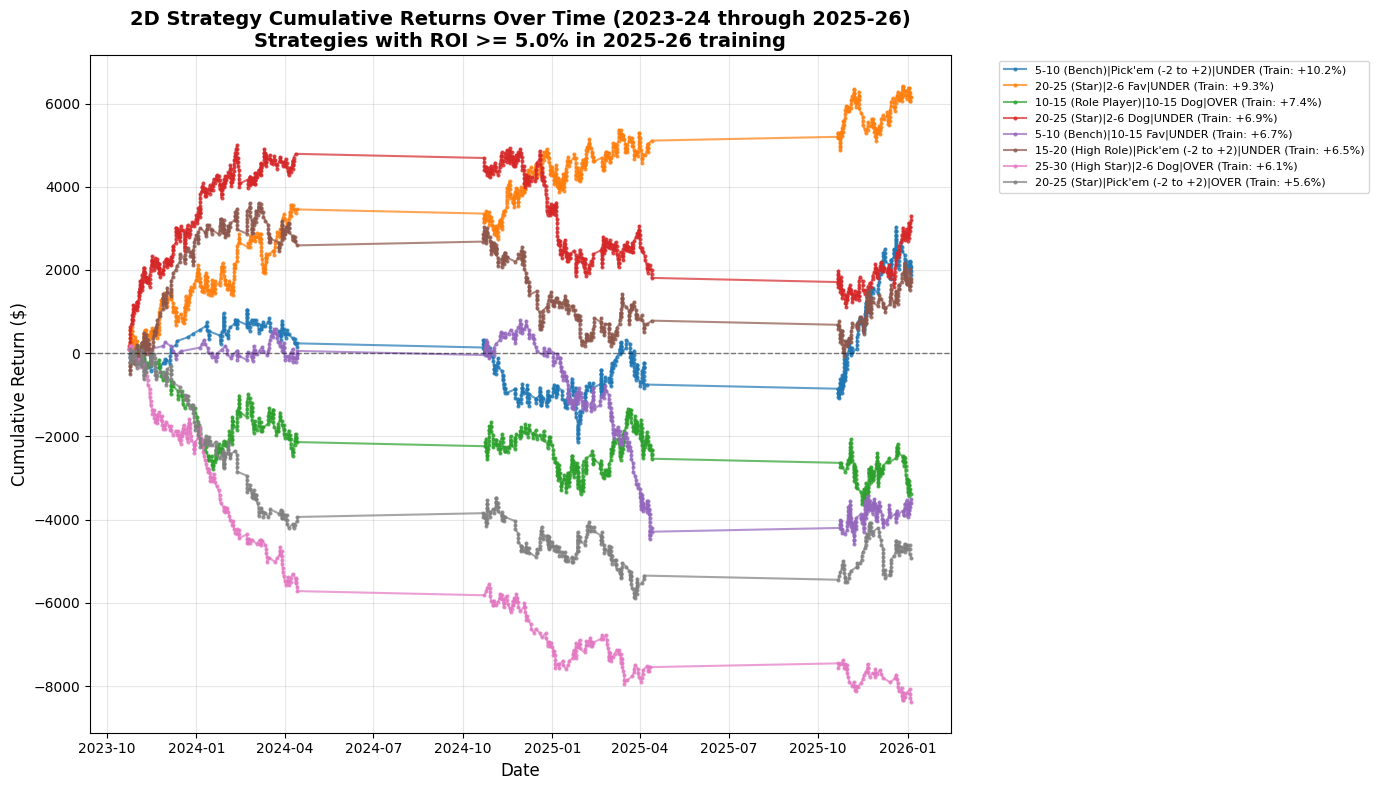

✅ Saved 3D strategy returns plot: tmp/3d_strategy_returns_over_time.png


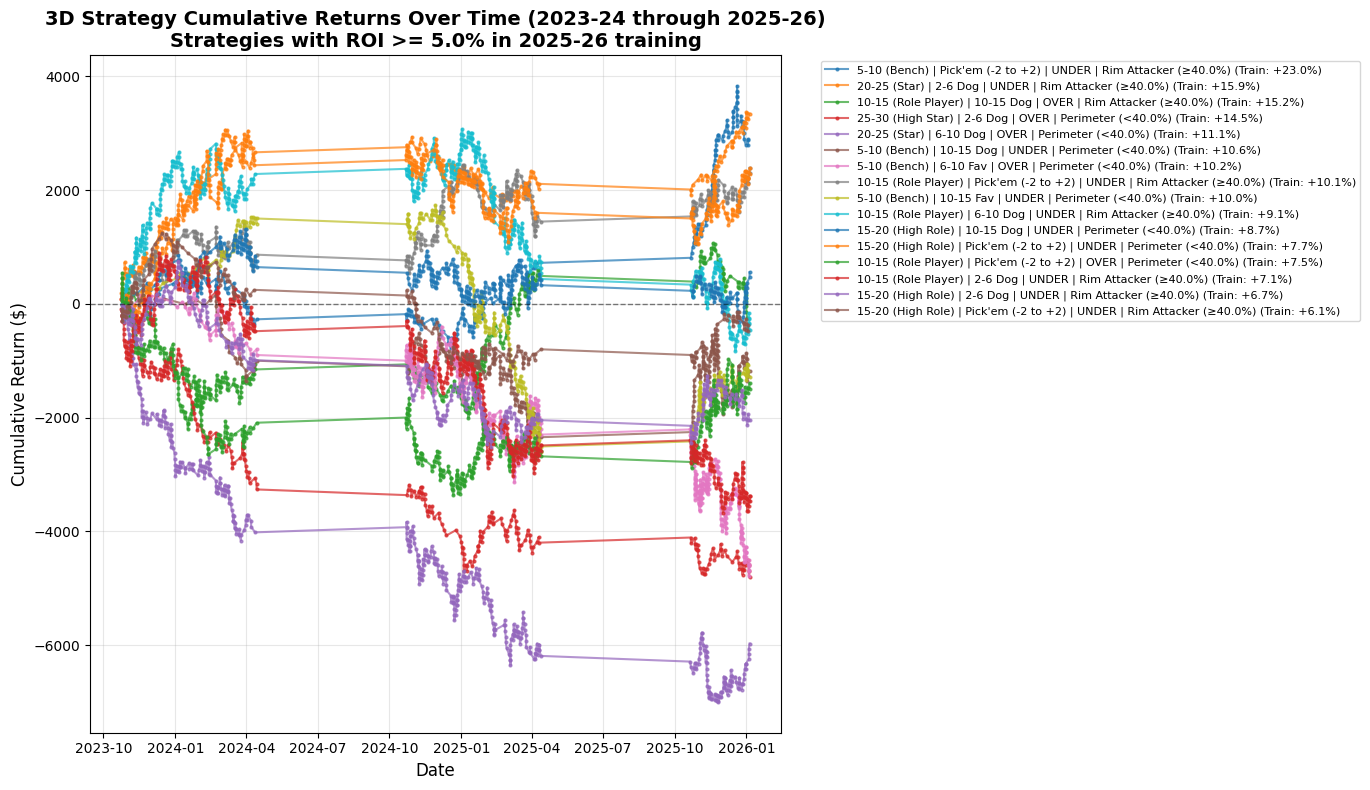


📊 2D STRATEGY SUMMARY

5-10 (Bench)|Pick'em (-2 to +2)|UNDER
  Training ROI: +10.2%
  Total Plays: 657
  W-L-P: 354-303-0
  Win Rate: 53.9%
  Final Return: $1,882.14

20-25 (Star)|2-6 Fav|UNDER
  Training ROI: +9.3%
  Total Plays: 832
  W-L-P: 468-364-0
  Win Rate: 56.2%
  Final Return: $6,145.88

10-15 (Role Player)|10-15 Dog|OVER
  Training ROI: +7.4%
  Total Plays: 744
  W-L-P: 371-371-2
  Win Rate: 50.0%
  Final Return: $-3,372.39

20-25 (Star)|2-6 Dog|UNDER
  Training ROI: +6.9%
  Total Plays: 872
  W-L-P: 473-397-2
  Win Rate: 54.4%
  Final Return: $3,300.43

5-10 (Bench)|10-15 Fav|UNDER
  Training ROI: +6.7%
  Total Plays: 524
  W-L-P: 254-267-3
  Win Rate: 48.8%
  Final Return: $-3,608.86

15-20 (High Role)|Pick'em (-2 to +2)|UNDER
  Training ROI: +6.5%
  Total Plays: 699
  W-L-P: 375-323-1
  Win Rate: 53.7%
  Final Return: $1,791.25

25-30 (High Star)|2-6 Dog|OVER
  Training ROI: +6.1%
  Total Plays: 395
  W-L-P: 163-232-0
  Win Rate: 41.3%
  Final Return: $-8,381.67

20-25 (

In [16]:
# %% [markdown]
# # Strategy Returns Over Time (2023-24 through 2025-26)
# 
# For each strategy with ROI >= 5.0% in 2025-26 training data:
# - Track cumulative returns across all 3 seasons (2023-24, 2024-25, 2025-26)
# - Plot each strategy as a separate line
# - 2025-26 data comes from live daily tracking (actual plays this season)
# - Shows if "winning" strategies in training actually made money historically
# - Separate graphs for 2D and 3D strategies

# %%
import pandas as pd
import boto3
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# %%
# Setup
s3_client = boto3.client('s3')
bucket = 'nba-betting-mt'

# %% [markdown]
# ## Step 1: Load 2025-26 Training Strategies (to identify winning strategies)

# %%
def load_training_strategies(strategy_type):
    """Load 2025-26 training strategies from S3"""
    if strategy_type == '2d':
        s3_key = 'data/03_intermediate/points_by_role_gamespread_strategies_2025-26.json'
    else:  # 3d
        s3_key = 'data/03_intermediate/points_by_role_gamespread_6feet_strategies_2025-26_rim40.json'
    
    try:
        response = s3_client.get_object(Bucket=bucket, Key=s3_key)
        data = json.loads(response['Body'].read().decode('utf-8'))
        
        # Extract strategies list
        if 'strategies' in data:
            strategies = data['strategies']
        else:
            strategies = data
        
        # Convert to DataFrame for easier filtering
        if isinstance(strategies, dict):
            strategies = list(strategies.values())
        
        df = pd.DataFrame(strategies)
        print(f"✅ Loaded {len(df)} {strategy_type.upper()} training strategies from 2025-26")
        return df
        
    except Exception as e:
        print(f"❌ Error loading {strategy_type.upper()} training strategies: {e}")
        return pd.DataFrame()

# Load both strategy types
training_2d = load_training_strategies('2d')
training_3d = load_training_strategies('3d')

# Filter to winning strategies (ROI >= 5.0%)
winning_2d = training_2d[training_2d['roi'] >= 5.0].copy()
winning_3d = training_3d[training_3d['roi'] >= 5.0].copy()

print(f"\n📊 Winning Strategies (ROI >= 5.0%):")
print(f"  2D: {len(winning_2d)} strategies")
print(f"  3D: {len(winning_3d)} strategies")

# %% [markdown]
# ## Step 2: Load Backtest Results (per-play data for all seasons)

# %%
def load_backtest_plays(strategy_type, seasons=['2023-24', '2024-25', '2025-26']):
    """Load detailed play-by-play backtest results from S3"""
    all_plays = []
    
    for season in seasons:
        s3_key = f'data/04_output/backtests/{strategy_type}/{season}/plays.csv'
        
        try:
            response = s3_client.get_object(Bucket=bucket, Key=s3_key)
            df = pd.read_csv(StringIO(response['Body'].read().decode('utf-8')))
            df['season'] = season
            all_plays.append(df)
            print(f"✅ Loaded {len(df)} {strategy_type.upper()} plays from {season} (backtest)")
        except Exception as e:
            print(f"⚠️  Skipping {season} {strategy_type.upper()}: {e}")
    
    if all_plays:
        return pd.concat(all_plays, ignore_index=True)
    else:
        return pd.DataFrame()

# Load backtest plays (all 3 seasons)
plays_2d = load_backtest_plays('2d')
plays_3d = load_backtest_plays('3d')

print(f"\n📊 Total Plays Loaded (All Seasons):")
print(f"  2D: {len(plays_2d):,} plays")
print(f"  3D: {len(plays_3d):,} plays")

# %% [markdown]
# ## Step 3: Calculate Cumulative Returns for Each Winning Strategy

# %%
def calculate_cumulative_returns(plays_df, winning_strategies_df, strategy_type):
    """
    Calculate cumulative returns over time for each winning strategy.
    
    Assumes:
    - $100 per bet
    - -100 odds (even money: win = +$100, loss = -$100)
    """
    results = []
    
    for idx, strat in winning_strategies_df.iterrows():
        # Create a unique identifier for this strategy
        strat_id = f"{strat['line_tier']}|{strat['spread_bin']}|{strat['bet_side']}"
        if strategy_type == '3d' and 'scorer_type' in strat:
            strat_id += f"|{strat['scorer_type']}"
        
        # Filter plays for this specific strategy
        strategy_plays = plays_df[
            (plays_df['line_tier'] == strat['line_tier']) &
            (plays_df['spread_bin'] == strat['spread_bin']) &
            (plays_df['bet_side'] == strat['bet_side'])
        ].copy()
        
        # For 3D, also match scorer_type
        if strategy_type == '3d' and 'scorer_type' in strat:
            strategy_plays = strategy_plays[
                strategy_plays['scorer_type'] == strat['scorer_type']
            ]
        
        if len(strategy_plays) == 0:
            continue
        
        # Sort by date
        strategy_plays = strategy_plays.sort_values('game_date')
        
        # Profit is already calculated in the plays CSV
        # Calculate cumulative return
        strategy_plays['cumulative_return'] = strategy_plays['profit'].cumsum()
        
        # Add strategy info
        strategy_plays['strategy_id'] = strat_id
        strategy_plays['training_roi'] = strat['roi']
        
        results.append(strategy_plays)
    
    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame()

# Calculate cumulative returns
returns_2d = calculate_cumulative_returns(plays_2d, winning_2d, '2d')
returns_3d = calculate_cumulative_returns(plays_3d, winning_3d, '3d')

print(f"\n📈 Cumulative Returns Calculated:")
print(f"  2D: {len(returns_2d):,} plays across {returns_2d['strategy_id'].nunique() if len(returns_2d) > 0 else 0} strategies")
print(f"  3D: {len(returns_3d):,} plays across {returns_3d['strategy_id'].nunique() if len(returns_3d) > 0 else 0} strategies")

# %% [markdown]
# ## Step 4: Plot Cumulative Returns (2D Strategies)

# %%
if len(returns_2d) > 0:
    plt.figure(figsize=(14, 8))
    
    for strategy_id in returns_2d['strategy_id'].unique():
        strategy_data = returns_2d[returns_2d['strategy_id'] == strategy_id].copy()
        
        # Convert date to numeric for plotting
        strategy_data['game_date'] = pd.to_datetime(strategy_data['game_date'])
        
        # Plot this strategy's cumulative return
        training_roi = strategy_data['training_roi'].iloc[0]
        label = f"{strategy_id} (Train: {training_roi:+.1f}%)"
        
        plt.plot(strategy_data['game_date'], 
                strategy_data['cumulative_return'],
                marker='o',
                markersize=2,
                alpha=0.7,
                label=label)
    
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return ($)', fontsize=12)
    plt.title('2D Strategy Cumulative Returns Over Time (2023-24 through 2025-26)\nStrategies with ROI >= 5.0% in 2025-26 training', 
              fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/Users/thomasmyles/dev/betting/tmp/2d_strategy_returns_over_time.png', dpi=300, bbox_inches='tight')
    print("✅ Saved 2D strategy returns plot: tmp/2d_strategy_returns_over_time.png")
    plt.show()
else:
    print("⚠️  No 2D strategy data to plot")

# %% [markdown]
# ## Step 5: Plot Cumulative Returns (3D Strategies)

# %%
if len(returns_3d) > 0:
    plt.figure(figsize=(14, 8))
    
    for strategy_id in returns_3d['strategy_id'].unique():
        strategy_data = returns_3d[returns_3d['strategy_id'] == strategy_id].copy()
        
        # Convert date to numeric for plotting
        strategy_data['game_date'] = pd.to_datetime(strategy_data['game_date'])
        
        # Plot this strategy's cumulative return
        training_roi = strategy_data['training_roi'].iloc[0]
        label = f"{strategy_id.replace('|', ' | ')} (Train: {training_roi:+.1f}%)"
        
        plt.plot(strategy_data['game_date'], 
                strategy_data['cumulative_return'],
                marker='o',
                markersize=2,
                alpha=0.7,
                label=label)
    
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return ($)', fontsize=12)
    plt.title('3D Strategy Cumulative Returns Over Time (2023-24 through 2025-26)\nStrategies with ROI >= 5.0% in 2025-26 training', 
              fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/Users/thomasmyles/dev/betting/tmp/3d_strategy_returns_over_time.png', dpi=300, bbox_inches='tight')
    print("✅ Saved 3D strategy returns plot: tmp/3d_strategy_returns_over_time.png")
    plt.show()
else:
    print("⚠️  No 3D strategy data to plot")

# %% [markdown]
# ## Step 6: Summary Statistics

# %%
def print_strategy_summary(returns_df, strategy_type):
    """Print summary statistics for each strategy"""
    print(f"\n{'='*80}")
    print(f"📊 {strategy_type.upper()} STRATEGY SUMMARY")
    print(f"{'='*80}")
    
    if len(returns_df) == 0:
        print("No data available")
        return
    
    for strategy_id in returns_df['strategy_id'].unique():
        strategy_data = returns_df[returns_df['strategy_id'] == strategy_id]
        
        final_return = strategy_data['cumulative_return'].iloc[-1]
        total_plays = len(strategy_data)
        wins = (strategy_data['result'] == 'WIN').sum()
        losses = (strategy_data['result'] == 'LOSS').sum()
        pushes = (strategy_data['result'] == 'PUSH').sum()
        win_rate = wins / (wins + losses) * 100 if (wins + losses) > 0 else 0
        training_roi = strategy_data['training_roi'].iloc[0]
        
        print(f"\n{strategy_id}")
        print(f"  Training ROI: {training_roi:+.1f}%")
        print(f"  Total Plays: {total_plays}")
        print(f"  W-L-P: {wins}-{losses}-{pushes}")
        print(f"  Win Rate: {win_rate:.1f}%")
        print(f"  Final Return: ${final_return:,.2f}")

print_strategy_summary(returns_2d, '2d')
print_strategy_summary(returns_3d, '3d')

# %%



In [17]:
# find resilient strategies


In [18]:
...

Ellipsis

In [ ]:
# %% [markdown]
# # Find Resilient Strategies (Profitable in 2+ Seasons)
# 
# Identifies strategies that show consistent profitability across multiple seasons:
# - Profitable in at least 2 out of 3 seasons
# - Positive overall cumulative returns
# - Prioritizes strategies profitable in 2023-24 AND 2025-26 (even if 2024-25 was bad)
# - These may represent real edges that are resilient to market shifts

# %%
import pandas as pd
import boto3
from io import StringIO
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# %%
# Setup
s3_client = boto3.client('s3')
bucket = 'nba-betting-mt'

# %% [markdown]
# ## Step 1: Load Training Strategies and Backtest Plays

# %%
def load_training_strategies(strategy_type):
    """Load 2025-26 training strategies from S3"""
    if strategy_type == '2d':
        s3_key = 'data/03_intermediate/points_by_role_gamespread_strategies_2025-26.json'
    else:  # 3d
        s3_key = 'data/03_intermediate/points_by_role_gamespread_6feet_strategies_2025-26_rim40.json'
    
    try:
        response = s3_client.get_object(Bucket=bucket, Key=s3_key)
        data = json.loads(response['Body'].read().decode('utf-8'))
        
        if 'strategies' in data:
            strategies = data['strategies']
        else:
            strategies = data
        
        if isinstance(strategies, dict):
            strategies = list(strategies.values())
        
        df = pd.DataFrame(strategies)
        print(f"✅ Loaded {len(df)} {strategy_type.upper()} training strategies from 2025-26")
        return df
        
    except Exception as e:
        print(f"❌ Error loading {strategy_type.upper()} training strategies: {e}")
        return pd.DataFrame()

def load_backtest_plays(strategy_type, seasons=['2023-24', '2024-25', '2025-26']):
    """Load detailed play-by-play backtest results from S3"""
    all_plays = []
    
    for season in seasons:
        s3_key = f'data/04_output/backtests/{strategy_type}/{season}/plays.csv'
        
        try:
            response = s3_client.get_object(Bucket=bucket, Key=s3_key)
            df = pd.read_csv(StringIO(response['Body'].read().decode('utf-8')))
            df['season'] = season
            all_plays.append(df)
            print(f"✅ Loaded {len(df)} {strategy_type.upper()} plays from {season}")
        except Exception as e:
            print(f"⚠️  Skipping {season} {strategy_type.upper()}: {e}")
    
    if all_plays:
        return pd.concat(all_plays, ignore_index=True)
    else:
        return pd.DataFrame()

# Load training strategies (for ROI >= 5% filter)
training_2d = load_training_strategies('2d')
training_3d = load_training_strategies('3d')

winning_2d = training_2d[training_2d['roi'] >= 5.0].copy()
winning_3d = training_3d[training_3d['roi'] >= 5.0].copy()

print(f"\n📊 Winning Strategies (ROI >= 5.0%):")
print(f"  2D: {len(winning_2d)} strategies")
print(f"  3D: {len(winning_3d)} strategies")

# Load backtest plays
plays_2d = load_backtest_plays('2d')
plays_3d = load_backtest_plays('3d')

print(f"\n📊 Total Plays Loaded:")
print(f"  2D: {len(plays_2d):,} plays")
print(f"  3D: {len(plays_3d):,} plays")

# %% [markdown]
# ## Step 2: Calculate Per-Season Performance for Each Strategy

# %%
def analyze_strategy_resilience(plays_df, winning_strategies_df, strategy_type):
    """
    Analyze each strategy's performance by season to find resilient ones.
    """
    results = []
    
    for idx, strat in winning_strategies_df.iterrows():
        # Create strategy identifier
        strat_id = f"{strat['line_tier']}|{strat['spread_bin']}|{strat['bet_side']}"
        if strategy_type == '3d' and 'scorer_type' in strat:
            strat_id += f"|{strat['scorer_type']}"
        
        # Filter plays for this specific strategy
        strategy_plays = plays_df[
            (plays_df['line_tier'] == strat['line_tier']) &
            (plays_df['spread_bin'] == strat['spread_bin']) &
            (plays_df['bet_side'] == strat['bet_side'])
        ].copy()
        
        if strategy_type == '3d' and 'scorer_type' in strat:
            strategy_plays = strategy_plays[
                strategy_plays['scorer_type'] == strat['scorer_type']
            ]
        
        if len(strategy_plays) == 0:
            continue
        
        # Calculate performance BY SEASON
        season_stats = {}
        for season in ['2023-24', '2024-25', '2025-26']:
            season_plays = strategy_plays[strategy_plays['season'] == season]
            
            if len(season_plays) > 0:
                wins = (season_plays['result'] == 'WIN').sum()
                losses = (season_plays['result'] == 'LOSS').sum()
                total_profit = season_plays['profit'].sum()
                
                season_stats[season] = {
                    'plays': len(season_plays),
                    'wins': wins,
                    'losses': losses,
                    'profit': total_profit,
                    'profitable': total_profit > 0
                }
            else:
                season_stats[season] = {
                    'plays': 0,
                    'wins': 0,
                    'losses': 0,
                    'profit': 0,
                    'profitable': False
                }
        
        # Calculate overall stats
        total_plays = len(strategy_plays)
        total_wins = (strategy_plays['result'] == 'WIN').sum()
        total_losses = (strategy_plays['result'] == 'LOSS').sum()
        total_profit = strategy_plays['profit'].sum()
        
        # Count profitable seasons
        profitable_seasons = sum(1 for s in season_stats.values() if s['profitable'])
        
        # Check if profitable in 2023-24 AND 2025-26
        profitable_bookends = (season_stats['2023-24']['profitable'] and 
                               season_stats['2025-26']['profitable'])
        
        results.append({
            'strategy_id': strat_id,
            'strategy_type': strategy_type,
            'line_tier': strat['line_tier'],
            'spread_bin': strat['spread_bin'],
            'bet_side': strat['bet_side'],
            'scorer_type': strat.get('scorer_type', 'N/A'),
            'training_roi': strat['roi'],
            
            # Overall stats
            'total_plays': total_plays,
            'total_profit': total_profit,
            'win_rate': (total_wins / (total_wins + total_losses) * 100) if (total_wins + total_losses) > 0 else 0,
            
            # Season-by-season
            'profit_2023_24': season_stats['2023-24']['profit'],
            'profit_2024_25': season_stats['2024-25']['profit'],
            'profit_2025_26': season_stats['2025-26']['profit'],
            'plays_2023_24': season_stats['2023-24']['plays'],
            'plays_2024_25': season_stats['2024-25']['plays'],
            'plays_2025_26': season_stats['2025-26']['plays'],
            
            # Resilience metrics
            'profitable_seasons_count': profitable_seasons,
            'profitable_in_bookends': profitable_bookends,  # 2023-24 AND 2025-26
            'overall_profitable': total_profit > 0
        })
    
    return pd.DataFrame(results)

print("\n📊 Analyzing strategy resilience across seasons...")
resilience_2d = analyze_strategy_resilience(plays_2d, winning_2d, '2d')
resilience_3d = analyze_strategy_resilience(plays_3d, winning_3d, '3d')

# %% [markdown]
# ## Step 3: Find Resilient Strategies

# %%
def find_resilient_strategies(resilience_df):
    """
    Find strategies that are:
    1. Profitable in 2+ seasons
    2. Have positive overall returns
    """
    resilient = resilience_df[
        (resilience_df['profitable_seasons_count'] >= 2) &
        (resilience_df['overall_profitable'] == True)
    ].copy()
    
    # Sort by: bookends first, then by total profit
    resilient['sort_key'] = resilient['profitable_in_bookends'].astype(int) * 1000000 + resilient['total_profit']
    resilient = resilient.sort_values('sort_key', ascending=False).drop('sort_key', axis=1)
    
    return resilient

resilient_2d = find_resilient_strategies(resilience_2d)
resilient_3d = find_resilient_strategies(resilience_3d)

print(f"\n{'='*80}")
print(f"🏆 RESILIENT STRATEGIES FOUND")
print(f"{'='*80}")
print(f"\n2D Strategies: {len(resilient_2d)} resilient strategies found")
print(f"3D Strategies: {len(resilient_3d)} resilient strategies found")

# %% [markdown]
# ## Step 4: Display Resilient Strategies

# %%
def display_resilient_strategies(resilient_df, strategy_type):
    """Display resilient strategies with detailed season breakdown"""
    
    if len(resilient_df) == 0:
        print(f"\n⚠️  No resilient {strategy_type.upper()} strategies found")
        return
    
    print(f"\n{'='*80}")
    print(f"📊 {strategy_type.upper()} RESILIENT STRATEGIES")
    print(f"{'='*80}")
    
    for idx, row in resilient_df.iterrows():
        bookend_flag = "⭐ BOOKENDS" if row['profitable_in_bookends'] else ""
        
        print(f"\n{bookend_flag}")
        print(f"Strategy: {row['line_tier']} | {row['spread_bin']} | {row['bet_side']}")
        if row['scorer_type'] != 'N/A':
            print(f"Scorer Type: {row['scorer_type']}")
        print(f"Training ROI: {row['training_roi']:+.1f}%")
        
        print(f"\n  Season-by-Season Performance:")
        print(f"    2023-24: ${row['profit_2023_24']:>8,.2f} ({row['plays_2023_24']:>3} plays) {'✅' if row['profit_2023_24'] > 0 else '❌'}")
        print(f"    2024-25: ${row['profit_2024_25']:>8,.2f} ({row['plays_2024_25']:>3} plays) {'✅' if row['profit_2024_25'] > 0 else '❌'}")
        print(f"    2025-26: ${row['profit_2025_26']:>8,.2f} ({row['plays_2025_26']:>3} plays) {'✅' if row['profit_2025_26'] > 0 else '❌'}")
        
        print(f"\n  Overall: ${row['total_profit']:,.2f} profit | {row['total_plays']} plays | {row['win_rate']:.1f}% win rate")
        print(f"  Profitable in {row['profitable_seasons_count']}/3 seasons")

display_resilient_strategies(resilient_2d, '2d')
display_resilient_strategies(resilient_3d, '3d')

# %% [markdown]
# ## Step 5: Summary Statistics

# %%
print(f"\n{'='*80}")
print(f"📊 SUMMARY")
print(f"{'='*80}")

# Count bookend strategies (profitable in 2023-24 AND 2025-26)
bookend_2d = len(resilient_2d[resilient_2d['profitable_in_bookends']])
bookend_3d = len(resilient_3d[resilient_3d['profitable_in_bookends']])

print(f"\n🎯 Strategies Profitable in 2023-24 AND 2025-26 (Bookends):")
print(f"  2D: {bookend_2d} strategies")
print(f"  3D: {bookend_3d} strategies")

if bookend_2d > 0 or bookend_3d > 0:
    print(f"\n💡 These 'bookend' strategies are especially interesting because:")
    print(f"   - They worked in 2 different seasons with different market conditions")
    print(f"   - 2024-25 might have been an anomaly (injuries, rule changes, etc.)")
    print(f"   - They represent potentially real edges that are resilient over time")

# Calculate total profit from resilient strategies
total_profit_2d = resilient_2d['total_profit'].sum() if len(resilient_2d) > 0 else 0
total_profit_3d = resilient_3d['total_profit'].sum() if len(resilient_3d) > 0 else 0

print(f"\n💰 Total Profit from Resilient Strategies:")
print(f"  2D: ${total_profit_2d:,.2f}")
print(f"  3D: ${total_profit_3d:,.2f}")
print(f"  Combined: ${total_profit_2d + total_profit_3d:,.2f}")

# %% [markdown]
# ## Step 6: Export Results

# %%
# Combine and export
if len(resilient_2d) > 0 or len(resilient_3d) > 0:
    all_resilient = pd.concat([resilient_2d, resilient_3d], ignore_index=True)
    
    output_file = 'resilient_strategies_summary.csv'
    all_resilient.to_csv(output_file, index=False)
    print(f"\n✅ Saved {len(all_resilient)} resilient strategies to: {output_file}")
    
    # Show preview
    display_cols = [
        'strategy_type', 'line_tier', 'spread_bin', 'bet_side', 'scorer_type',
        'profitable_in_bookends', 'profitable_seasons_count',
        'profit_2023_24', 'profit_2024_25', 'profit_2025_26',
        'total_profit', 'total_plays', 'win_rate'
    ]
    print(f"\nPreview:")
    print(all_resilient[display_cols].head(20))
else:
    print(f"\n⚠️  No resilient strategies found to export")

# %%



✅ Loaded 70 2D training strategies from 2025-26
✅ Loaded 100 3D training strategies from 2025-26

📊 Winning Strategies (ROI >= 5.0%):
  2D: 8 strategies
  3D: 16 strategies
✅ Loaded 1785 2D plays from 2023-24
✅ Loaded 2268 2D plays from 2024-25
✅ Loaded 1164 2D plays from 2025-26
✅ Loaded 2081 3D plays from 2023-24
✅ Loaded 2842 3D plays from 2024-25
✅ Loaded 1570 3D plays from 2025-26

📊 Total Plays Loaded:
  2D: 5,217 plays
  3D: 6,493 plays

📊 Analyzing strategy resilience across seasons...

🏆 RESILIENT STRATEGIES FOUND

2D Strategies: 4 resilient strategies found
3D Strategies: 5 resilient strategies found

📊 2D RESILIENT STRATEGIES

⭐ BOOKENDS
Strategy: 20-25 (Star) | 2-6 Fav | UNDER
Training ROI: +9.3%

  Season-by-Season Performance:
    2023-24: $3,454.71 (311 plays) ✅
    2024-25: $1,654.73 (371 plays) ✅
    2025-26: $1,036.44 (150 plays) ✅

  Overall: $6,145.88 profit | 832 plays | 56.2% win rate
  Profitable in 3/3 seasons

⭐ BOOKENDS
Strategy: 20-25 (Star) | 2-6 Dog | UNDER

In [23]:
# look at the one that was profitable , not bookends
reqs = (all_resilient['profitable_in_bookends'] == False)
all_resilient[display_cols][reqs]

,strategy_type,line_tier,spread_bin,bet_side,scorer_type,profitable_in_bookends,profitable_seasons_count,profit_2023_24,profit_2024_25,profit_2025_26,total_profit,total_plays,win_rate
8,3d,5-10 (Bench),Pick'em (-2 to +2),UNDER,Rim Attacker (≥40.0%),False,2,-272.69,990.96,2163.69,2881.96,269,57.992565


In [25]:
# sort by total profit, then win rate
all_resilient[display_cols].sort_values(by=['total_profit', 'win_rate'], ascending=False)

,strategy_type,line_tier,spread_bin,bet_side,scorer_type,profitable_in_bookends,profitable_seasons_count,profit_2023_24,profit_2024_25,profit_2025_26,total_profit,total_plays,win_rate
0,2d,20-25 (Star),2-6 Fav,UNDER,N/A,True,3,3454.71,1654.73,1036.44,6145.88,832,56.250000
4,3d,20-25 (Star),2-6 Dog,UNDER,Rim Attacker (≥40.0%),True,2,2663.72,-554.51,1236.39,3345.60,273,58.823529
1,2d,20-25 (Star),2-6 Dog,UNDER,N/A,True,2,4791.11,-2981.67,1490.99,3300.43,872,54.367816
8,3d,5-10 (Bench),Pick'em (-2 to +2),UNDER,Rim Attacker (≥40.0%),False,2,-272.69,990.96,2163.69,2881.96,269,57.992565
5,3d,10-15 (Role Player),Pick'em (-2 to +2),UNDER,Rim Attacker (≥40.0%),True,3,863.71,581.90,945.50,2391.11,399,55.527638
6,3d,15-20 (High Role),Pick'em (-2 to +2),UNDER,Perimeter (<40.0%),True,2,2436.45,-836.28,781.87,2382.04,443,55.203620
2,2d,5-10 (Bench),Pick'em (-2 to +2),UNDER,N/A,True,2,236.43,-990.77,2636.48,1882.14,657,53.881279
3,2d,15-20 (High Role),Pick'em (-2 to +2),UNDER,N/A,True,2,2591.05,-1808.97,1009.17,1791.25,699,53.724928
7,3d,15-20 (High Role),10-15 Dog,UNDER,Perimeter (<40.0%),True,2,645.51,-318.10,227.31,554.72,362,53.185596


In [26]:
# look at strategies that were profitable in all 3 seasons

# sort by total profit, then win rate
reqs = (all_resilient['profitable_seasons_count'] == 3)
all_resilient[display_cols][reqs].sort_values(by=['total_profit', 'win_rate'], ascending=False)

,strategy_type,line_tier,spread_bin,bet_side,scorer_type,profitable_in_bookends,profitable_seasons_count,profit_2023_24,profit_2024_25,profit_2025_26,total_profit,total_plays,win_rate
0,2d,20-25 (Star),2-6 Fav,UNDER,N/A,True,3,3454.71,1654.73,1036.44,6145.88,832,56.250000
5,3d,10-15 (Role Player),Pick'em (-2 to +2),UNDER,Rim Attacker (≥40.0%),True,3,863.71,581.90,945.50,2391.11,399,55.527638
